#**This is a 'model' Classifictaion/Comparision between differnt sikit learn models**

Data used in this project : [kaggle Diabetes prediction dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset)

**'Models' we may compare on this project are :**
  - LogisticRegressor
  - KNN
  - SVM
  - RandomForestRegressor
  - Gradient Boosting / XGBoost


##**Importing Necessary Liberies for future use :**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report , accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve

For this project I may fetch the data from my personal Drive, thus I must connect the Drive to the program

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'covid-19.csv',
 'Indian_rental_prices.csv',
 'House Price India.csv',
 'Housing_price_prediction_.pkl',
 'Housing_price_model.joblib',
 'Housing_price_prediction_.joblib',
 'diabetes_prediction_dataset.csv']

In [4]:
df=pd.read_csv('/content/drive/MyDrive/diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.shape

(100000, 9)

##**Preprocessing**  
- Transforing the texts to numbers using 'OneHotEncoder'
- Scaling the data using StandardScaler
- Filling blank space with SimpleImputer(starategy='most_fremost_frequent')

In [5]:
x=df.drop('diabetes',axis=1)
y=df['diabetes']

In [6]:
x.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,Female,80.0,0,1,never,25.19,6.6,140
1,Female,54.0,0,0,No Info,27.32,6.6,80
2,Male,28.0,0,0,never,27.32,5.7,158
3,Female,36.0,0,0,current,23.45,5.0,155
4,Male,76.0,1,1,current,20.14,4.8,155


In [7]:
num_column=['age','bmi','HbA1c_level','blood_glucose_level']
catogerical_column=['gender','smoking_history']

num_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('sclaer',StandardScaler()),
])

cat_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder())
])

data_processing =ColumnTransformer(transformers=[
    ('num',num_pipeline,num_column),
    ('cat',cat_pipeline,catogerical_column)
])

In [8]:
data_processing

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('sclaer', StandardScaler())]),
                                 ['age', 'bmi', 'HbA1c_level',
                                  'blood_glucose_level']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder', OneHotEncoder())]),
                                 ['gender', 'smoking_history'])])

In [9]:
x_train, x_test, y_train, y_test =train_test_split(x,y,test_size=.3,random_state=42)

##**Working With Models :**

###LogisticRegression

In [ ]:
logistic_regressor_pipe=Pipeline(steps=[
    ('preprocessing',data_processing),
    ('model',LogisticRegression())
])

logistic_regressor_pipe.fit(x_train,y_train)

y_predict=logistic_regressor_pipe.predict(x_test)
y_probablity=logistic_regressor_pipe.predict_proba(x_test)[:,1]

print(f'''
Classification Report :

{classification_report(y_test,y_predict)}

Confusion Matrix      :

{confusion_matrix(y_test,y_predict)}

ROC-AUC               : {roc_auc_score(y_test,y_probablity)}
''')




Classification Report : 

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     27453
           1       0.87      0.60      0.71      2547

    accuracy                           0.96     30000
   macro avg       0.92      0.80      0.85     30000
weighted avg       0.96      0.96      0.96     30000

      
Confusion Matrix      : 

[[27223   230]
 [ 1009  1538]]
      
ROC-AUC               : 0.9599608945815677



###KNN

In [ ]:
knn_pipe=Pipeline(steps=[
    ('processing',data_processing),
    ('model',KNeighborsClassifier())
])

knn_pipe.fit(x_train,y_train)

knn_predict=knn_pipe.predict(x_test)
knn_predict_proba=knn_pipe.predict_proba(x_test)[:,1]

print(f'''
Classification Report :

{classification_report(y_test,knn_predict)}

Confusion Matrix :

{confusion_matrix(y_test,knn_predict)}

ROC AUC Score : {roc_auc_score(y_test,knn_predict_proba)}
''')



Classification Report : 

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     27453
           1       0.91      0.61      0.73      2547

    accuracy                           0.96     30000
   macro avg       0.94      0.80      0.86     30000
weighted avg       0.96      0.96      0.96     30000

      
Confusion Matrix :

[[27299   154]
 [  983  1564]]
      
ROC AUC Score : 0.9051183254398412



###SVM

In [ ]:
svm_pipe=Pipeline(steps=[
    ('preprocessing',data_processing),
    ('model',SVC(probability=True))
])

svm_pipe.fit(x_train,y_train)
svm_predict=svm_pipe.predict(x_test)
svm_predict_proba=svm_pipe.predict_proba(x_test)[:,1]

print(f'''
Classification Report :
{classification_report(y_test,svm_predict)}

Confusion Matrix :
{confusion_matrix(y_test,svm_predict)}

ROC-AUC Score : {roc_auc_score(y_test,svm_predict_proba)}
''')


Classification Report : 
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     27453
           1       0.99      0.58      0.73      2547

    accuracy                           0.96     30000
   macro avg       0.98      0.79      0.86     30000
weighted avg       0.97      0.96      0.96     30000

      
Confusion Matrix : 
[[27441    12]
 [ 1069  1478]]
      
ROC-AUC Score : 0.9340848107736431



###RandomForestRegressor

In [ ]:
rf_pipe=Pipeline(steps=[
    ('preprocessing',data_processing),
    ('model',RandomForestClassifier())
])

rf_pipe.fit(x_train,y_train)

rf_predict=rf_pipe.predict(x_test)
rf_predict_proba=rf_pipe.predict_proba(x_test)[:,1]

print(f'''
Classification Report :
{classification_report(y_test,rf_predict)}
Confusion Matrix :
{confusion_matrix(y_test,rf_predict)}
ROC-AUC Scores :
{roc_auc_score(y_test,rf_predict_proba)}
''')


Classification Report :
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27453
           1       0.95      0.68      0.79      2547

    accuracy                           0.97     30000
   macro avg       0.96      0.84      0.89     30000
weighted avg       0.97      0.97      0.97     30000

Confusion Matrix :
[[27354    99]
 [  811  1736]]
ROC-AUC Scores :
0.9591332173797239



###XGBClassifier

In [12]:
xgb_pipe=Pipeline(steps=[
    ('preprocessing',data_processing),
    ('model',XGBClassifier(random_state=42,eval_matric='logloss'))
])

xgb_pipe.fit(x_train,y_train)

xgb_predict=xgb_pipe.predict(x_test)
xgb_predict_proba=xgb_pipe.predict_proba(x_test)[:,1]

print(f'''
Classification Report :
{classification_report(y_test,xgb_predict)}
Confusion Matrix :
{confusion_matrix(y_test,xgb_predict)}
ROC-AUC Score : {roc_auc_score(y_test,xgb_predict_proba)}
''')

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [10:05:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "eval_matric" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report :
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27453
           1       0.96      0.68      0.80      2547

    accuracy                           0.97     30000
   macro avg       0.97      0.84      0.89     30000
weighted avg       0.97      0.97      0.97     30000

Confusion Matrix :
[[27383    70]
 [  810  1737]]
ROC-AUC Score : 0.9765060722476022



**From all the 'experimental' data we may say XGBClassifier have performed the best among all the models in our consideration,**

**thus we may try to optimize it to furter extent.**

##**Optimizing 'XGB'**

In [13]:
#custom_threshold=.3

for i in [.1,.2,.3,.4,.5]:

  y_predict_custom=(xgb_predict_proba>=i).astype(int)
  print(f'''
  XGB with custom_threshold >= {i}

  Classificatin Report :
  {classification_report(y_test,y_predict_custom)}

  Confusion Matrix :
  {confusion_matrix(y_test,y_predict_custom)}

  ''')


  XGB with custom_threshold >= 0.1

  Classificatin Report :
                precision    recall  f1-score   support

           0       0.99      0.92      0.95     27453
           1       0.50      0.89      0.64      2547

    accuracy                           0.92     30000
   macro avg       0.75      0.90      0.80     30000
weighted avg       0.95      0.92      0.93     30000


  Confusion Matrix :
  [[25208  2245]
 [  286  2261]]

  

  XGB with custom_threshold >= 0.2

  Classificatin Report :
                precision    recall  f1-score   support

           0       0.98      0.97      0.97     27453
           1       0.70      0.79      0.74      2547

    accuracy                           0.95     30000
   macro avg       0.84      0.88      0.86     30000
weighted avg       0.96      0.95      0.96     30000


  Confusion Matrix :
  [[26602   851]
 [  532  2015]]

  

  XGB with custom_threshold >= 0.3

  Classificatin Report :
                precision    recall  f

In [14]:
precision,recall,threshold=precision_recall_curve(y_test,xgb_predict_proba)

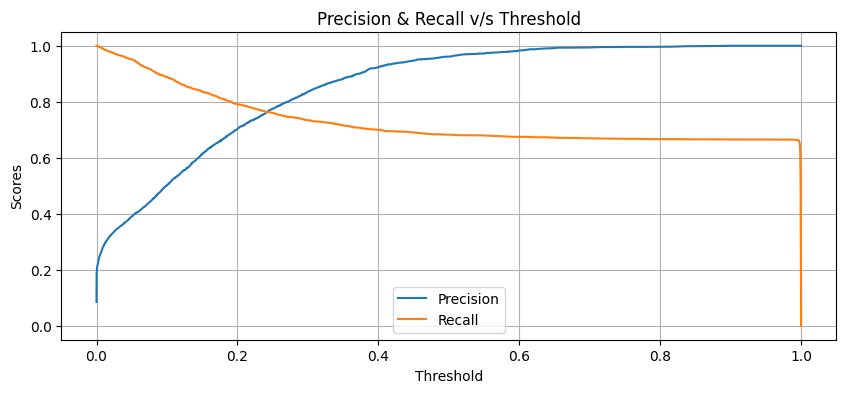

In [15]:
plt.figure(figsize=(10,4))
plt.plot(threshold,precision[:-1],label='Precision')
plt.plot(threshold,recall[:-1],label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Scores')
plt.title('Precision & Recall v/s Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
fix_threshold=.23

y_predict_fix=(xgb_predict_proba>=fix_threshold).astype(int)

print(f'''
XGBClassifier with fix_threshold >= 0.23

----------------------------------------

Classification Report :
{classification_report(y_test,y_predict_fix)}

Confusion Report :
{confusion_matrix(y_test,y_predict_fix)}

ROC-AUC Score : {roc_auc_score(y_test,y_predict_fix)}

----------------------------------------
''')



XGBClassifier with fix_threshold >= 0.23

----------------------------------------

Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     27453
           1       0.74      0.77      0.76      2547

    accuracy                           0.96     30000
   macro avg       0.86      0.87      0.87     30000
weighted avg       0.96      0.96      0.96     30000

      
Confusion Report :
[[26779   674]
 [  581  1966]]
      
ROC-AUC Score : 0.8736687226915756
      
----------------------------------------



**Saving The Finalized Model**

In [20]:
import joblib
joblib.dump(xgb_pipe,'/content/drive/MyDrive/model_classification_.joblib')

['/content/drive/MyDrive/model_classification_.joblib']